# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

/home/lqr/miniconda3/envs/omics/lib/python3.9/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
data_a

array([[0.        , 0.        , 0.        , ..., 0.        , 1.56603711,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        1.18721369],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.50787739],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [5]:
data_ab = data_a + data_b

view_a_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_b)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_ab)

In [6]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [7]:
view_a_label, _, _ = phenograph.cluster(view_a_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_b_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10979056358337402 seconds
Jaccard graph constructed in 0.3119039535522461 seconds
Wrote graph to binary file in 0.0062220096588134766 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.592967
Louvain completed 21 runs in 0.3271944522857666 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.0044512748718262 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08665728569030762 seconds
Jaccard graph constructed in 0.28325963020324707 seconds
Wrote graph to binary file in 0.005166769027709961 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.706175
Louvain completed 21 runs in 0.3086392879486084 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.9653809070587158 seconds
Finding 30 nearest neighbors using minko

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [8]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_a_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_b_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

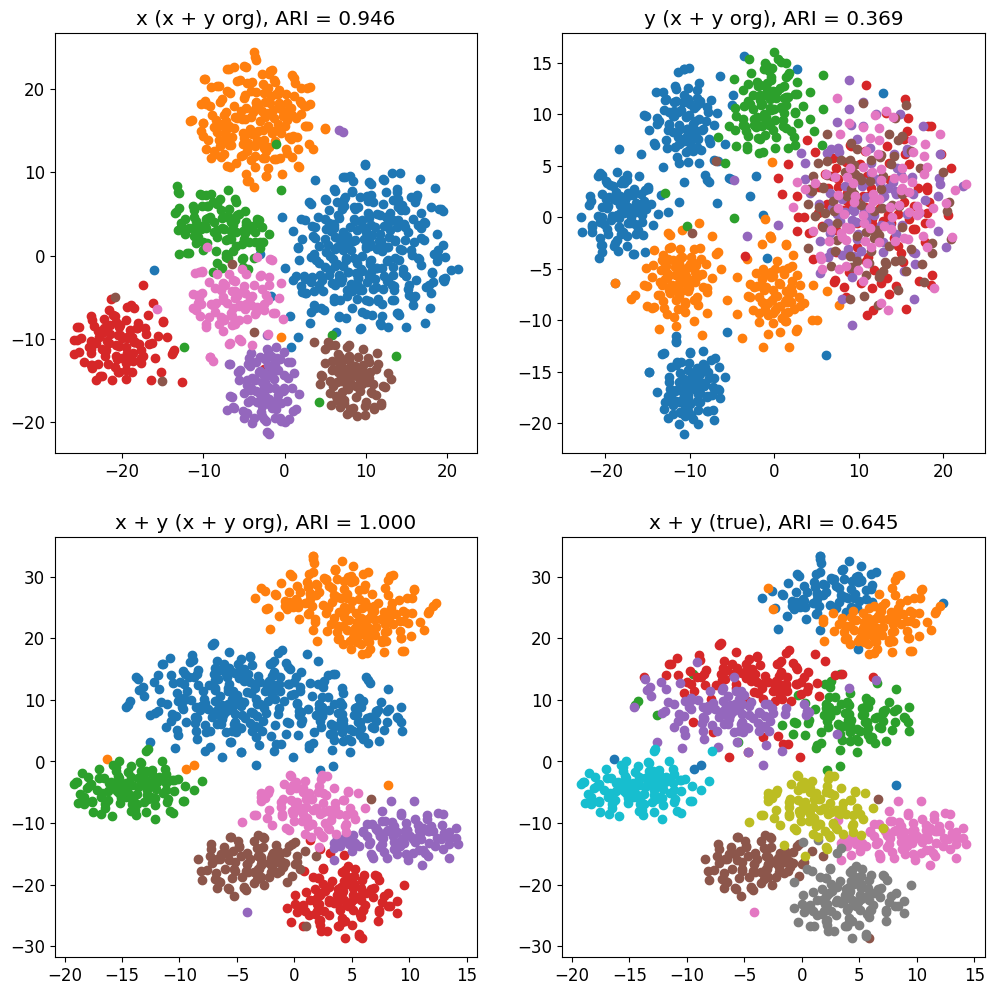

In [9]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('x (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

plt.subplot(2, 2, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (true), ARI = %01.3f' % adjusted_rand_score(view_ab_label, label_true))
plt.show()

In [10]:
outputs = muse.dual_muse_fit_predict(
    [data_a, data_b],
    [data_ab],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=100,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 259.30 	 sc loss: 140.90 	 st loss: 99.09 	 infoNCE: 19.31 	 sc recon: 0.04 	 st recon: 0.04 	 sc sparse: 140.87 	 st sparse: 99.06 	 sc trip: 0.00 	 st trip: 0.00


#epoch: 25/200 	 total loss: 260.29 	 sc loss: 136.68 	 st loss: 96.14 	 infoNCE: 27.47 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 136.67 	 st sparse: 96.12 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 247.32 	 sc loss: 132.58 	 st loss: 93.26 	 infoNCE: 21.47 	 sc recon: 0.01 	 st recon: 0.02 	 sc sparse: 132.57 	 st sparse: 93.25 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 75/200 	 total loss: 247.99 	 sc loss: 128.56 	 st loss: 90.45 	 infoNCE: 28.97 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 128.55 	 st sparse: 90.44 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 232.56 	 sc loss: 124.62 	 st loss: 87.70 	 infoNCE: 20.25 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 124.61 	 st sparse: 87.68 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 125/200 	 total loss: 229.08 	 sc loss: 120.75 	 st loss: 85.00 	 infoNCE: 23.33 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 120.74 	 st sparse: 84.98 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 224

## Perform clustering
PhenoGraph clustering

In [11]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
muse_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)
# 用kmeans聚类
from sklearn.cluster import KMeans
n_clusters = np.unique(view_ab_label).shape[0]
print(f"n_clusters: {n_clusters}")
kmeans_sc = KMeans(n_clusters=n_clusters).fit_predict(latent_sc)
kmeans_st = KMeans(n_clusters=n_clusters).fit_predict(latent_st)


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08119416236877441 seconds
Jaccard graph constructed in 0.37987327575683594 seconds
Wrote graph to binary file in 0.007719278335571289 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.899183
Louvain completed 21 runs in 0.6329214572906494 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.5590996742248535 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07133054733276367 seconds
Jaccard graph constructed in 0.3909754753112793 seconds
Wrote graph to binary file in 0.009846687316894531 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.870519
Louvain completed 21 runs in 0.53741455078125 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.4248857498168945 seconds
n_clusters: 7


In [12]:
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (1000, 100)
latent_st: (1000, 100)
reconstruct_sc: (2, 1000, 500)
reconstruct_st: (1, 1000, 500)
encoded_sc: (2, 1000, 128)
encoded_st: (1, 1000, 128)


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [13]:
# import umap
# # 降维
# kmeans_st = KMeans(n_clusters=6, random_state=42).fit_predict(latent_sc)
# Y_tsne = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
# Y_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(latent_sc)

In [14]:
# TSNE UMAP 对比
# print(np.unique(view_ab_label))
# print(np.unique(muse_label_sc))
# print(np.unique(muse_label_st))


# # 创建图形
# fig = plt.figure(figsize=(12, 6))

# # TSNE 2D子图
# ax1 = fig.add_subplot(121)
# for i in np.unique(kmeans_st):
#     idx = np.nonzero(kmeans_st == i)[0]
#     ax1.scatter(Y_tsne[idx, 0], Y_tsne[idx, 1], label=f'Cluster {i}')
# ax1.set_title('t-SNE 2D (ARI = %.3f)' % adjusted_rand_score(view_ab_label, kmeans_st))
# ax1.set_xlabel('t-SNE1')
# ax1.set_ylabel('t-SNE2')
# ax1.legend()

# # UMAP 2D子图
# ax2 = fig.add_subplot(122)
# for i in np.unique(kmeans_st):
#     idx = np.nonzero(kmeans_st == i)[0]
#     ax2.scatter(Y_umap[idx, 0], Y_umap[idx, 1], label=f'Cluster {i}')
# ax2.set_title('UMAP 2D (ARI = %.3f)' % adjusted_rand_score(view_ab_label, kmeans_st))
# ax2.set_xlabel('UMAP1')
# ax2.set_ylabel('UMAP2')
# ax2.legend()

# # 调整布局
# plt.tight_layout()
# plt.show()

In [15]:
# # 3D可视化
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # 降维
# Y_tsne = TSNE(n_components=3, random_state=42).fit_transform(latent_st)
# Y_umap = umap.UMAP(n_components=3, random_state=42).fit_transform(latent_st)
# kmeans_st_tsne = KMeans(n_clusters=6, random_state=42).fit_predict(Y_tsne)
# kmeans_st_umap = KMeans(n_clusters=6, random_state=42).fit_predict(Y_umap)

# # 创建子图
# fig = make_subplots(
#     rows=1, cols=2,
#     specs=[[{'type': 'scene'}, {'type': 'scene'}]],
#     subplot_titles=('t-SNE 3D', 'UMAP 3D')
# )

# # 添加t-SNE散点图
# for i in np.unique(kmeans_st_tsne):
#     idx = np.nonzero(kmeans_st_tsne == i)[0]
#     fig.add_trace(
#         go.Scatter3d(
#             x=Y_tsne[idx, 0],
#             y=Y_tsne[idx, 1],
#             z=Y_tsne[idx, 2],
#             mode='markers',
#             marker=dict(size=4),
#             name=f'Cluster {i}',
#         ),
#         row=1, col=1
#     )

# # 添加UMAP散点图
# for i in np.unique(kmeans_st_umap):
#     idx = np.nonzero(kmeans_st_umap == i)[0]
#     fig.add_trace(
#         go.Scatter3d(
#             x=Y_umap[idx, 0],
#             y=Y_umap[idx, 1],
#             z=Y_umap[idx, 2],
#             mode='markers',
#             marker=dict(size=4),
#             name=f'Cluster {i}',
#             showlegend=False  # 不重复显示图例
#         ),
#         row=1, col=2
#     )

# # 更新布局
# fig.update_layout(
#     title_text=f"3D Visualization (ARI = {adjusted_rand_score(view_ab_label, kmeans_st):.3f})",
#     width=1500,
#     height=600,
# )

# # 更新每个子图的坐标轴标签
# fig.update_scenes(
#     row=1, col=1,
#     xaxis_title="t-SNE1",
#     yaxis_title="t-SNE2",
#     zaxis_title="t-SNE3"
# )

# fig.update_scenes(
#     row=1, col=2,
#     xaxis_title="UMAP1",
#     yaxis_title="UMAP2",
#     zaxis_title="UMAP3"
# )

# # 显示图形
# fig.show()

# # 可选：保存为HTML文件
# # fig.write_html("3d_visualization.html")

In [16]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

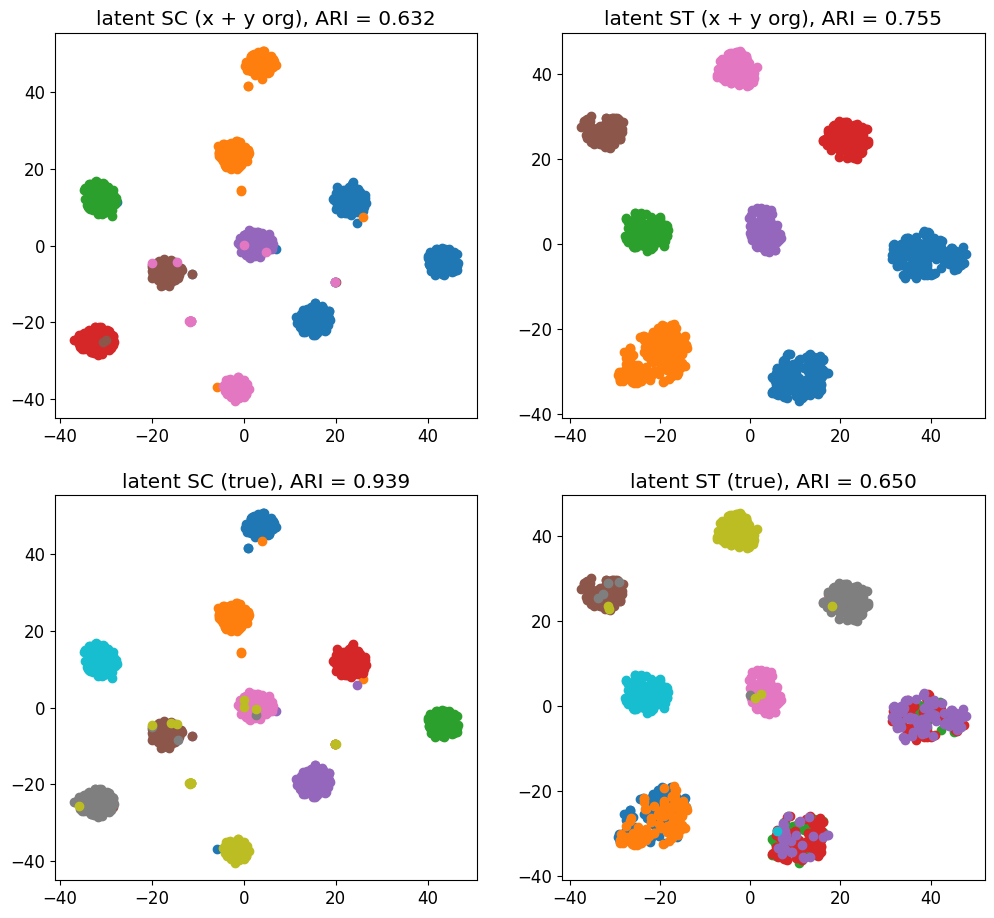

In [17]:
plt.figure(figsize=(12, 11))
plt.subplot(2, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_sc))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_st))

plt.subplot(2, 2, 3)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

In [18]:
print('phenograph SC and ST ARI: ', adjusted_rand_score(muse_label_sc, muse_label_st))
print('kmeans SC and ST ARI: ', adjusted_rand_score(kmeans_sc, kmeans_st))

phenograph SC and ST ARI:  0.6392194131940231
kmeans SC and ST ARI:  0.6197977450192113


In [19]:
import os
os.makedirs('latent_sc_st', exist_ok=True)
np.save(f'latent_sc_st/latent_sc.npy', latent_sc)
np.save(f'latent_sc_st/latent_st.npy', latent_st)

In [20]:
import sim_tangram.train_tangram as tg_cca
import torch

# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

RuntimeError: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero.

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 13%|█▎        | 67/500 [00:00<00:00, 653.28it/s]

100%|██████████| 500/500 [00:00<00:00, 644.55it/s]


Epoch 500: Loss -1.7772297859191895
[[10.125517    8.411572   -2.2782576  ... -1.0879134  -1.117726
   5.2802186 ]
 [ 6.186655    9.089594   -1.7900332  ...  1.4091877  -1.9293603
   0.68865615]
 [ 0.8766918  -2.509205    9.434986   ...  4.971846   -3.7552125
  -2.4258401 ]
 ...
 [-1.3547082  -0.29960877  3.386473   ...  9.437041    2.2324197
  -1.0197712 ]
 [-3.084321   -2.4486992  -1.8925691  ... -2.7366135   9.646797
   1.1396129 ]
 [-2.9947033  -0.50760967 -0.6828171  ... -2.8365362  -0.51722395
   9.610394  ]]


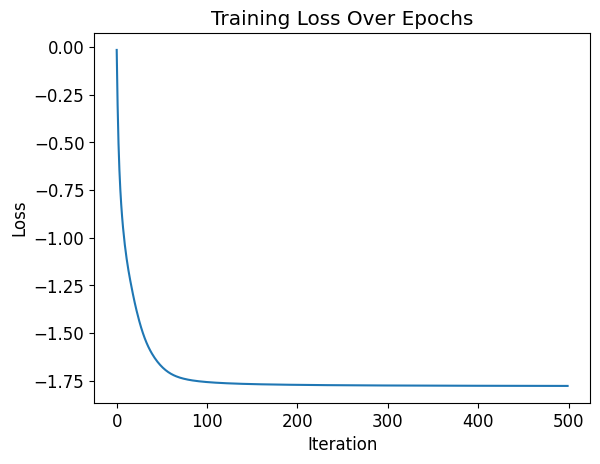

In [37]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0')],
    [torch.tensor(latent_st, device='cuda:0')],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [38]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:  495	28:   28	29:   29	
**************************************************


In [39]:
# 输出cos对角线的元素
for i in range(len(cos_mapping)):
    if i < 30:
        print(cos[i, i], end="\t")

0.623047	0.6565851	0.6422967	0.58930993	0.62111485	0.62950253	0.611312	0.5729185	0.5715573	0.55742717	0.52820665	0.60524714	0.6227677	0.5419623	0.6386081	0.6076534	0.6337968	0.6171352	0.6617371	0.63891727	0.5591112	0.6076168	0.61293334	0.55771196	0.59818184	0.607196	0.63823134	0.63411576	0.62853813	0.56811565	

In [41]:
# 计算acc
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 1.0
tangram accuracy: 0.877
cos_tg accuracy: 0.911
